# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:** 32 x 32 = **1024** valores por imagen. Como ya está en escala de grises hay un solo canal; en RGB serían 3072.

## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


In [5]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


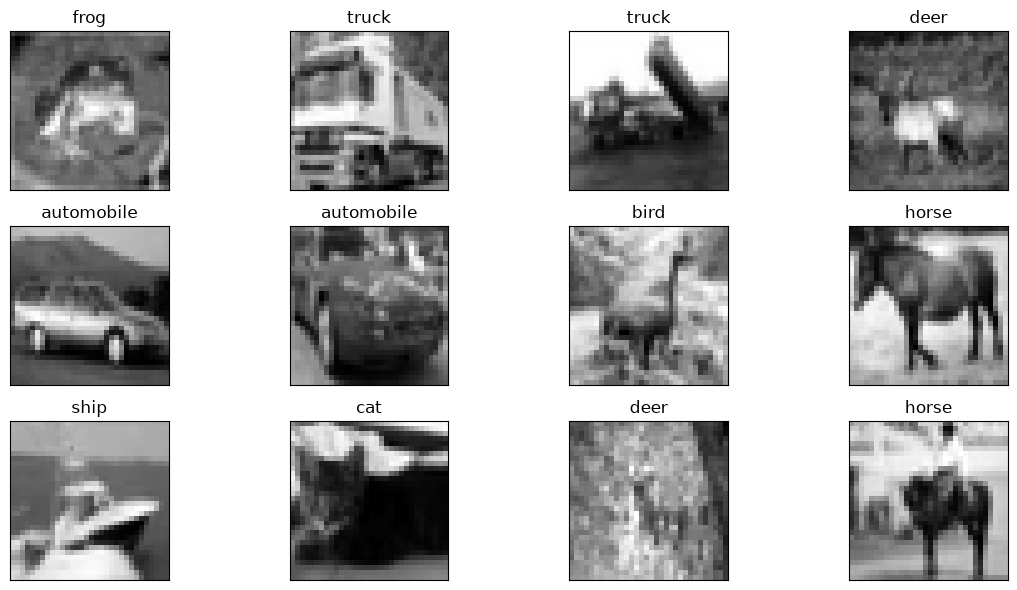

In [6]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [7]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque `Dense` trabaja con vectores: cada neurona multiplica cada entrada por un peso y suma. La imagen viene como matriz de 32x32, entonces Flatten la convierte en un vector de 1024 valores para poder conectarla a la capa Dense.

**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:** Porque CIFAR10 tiene 10 categorías y necesitamos un logit por cada una. La clase predicha es la neurona con el logit más alto.

**4.** ¿Qué función cumple `ReLU`?

**Respuesta:** ReLU convierte los valores negativos en 0 y deja los positivos igual. Así la red deja de ser una simple transformación lineal y puede aprender relaciones no lineales entre los píxeles; sin ReLU las dos capas Dense equivaldrían a una sola capa lineal.

---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [9]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:** Porque la última capa no tiene softmax, entonces la red entrega logits y no probabilidades. Con `from_logits=True` la pérdida aplica softmax internamente antes de calcular la cross entropy, de forma más estable numéricamente. Si pusiéramos False estaría tratando los logits como si ya fueran probabilidades.

---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [10]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)

Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 5:51 450ms/step - accuracy: 0.0938 - loss: 2.4658

 34/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1282 - loss: 2.3077    

 69/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1576 - loss: 2.2437

106/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1713 - loss: 2.2074

...

656/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3813 - loss: 1.7552

692/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3831 - loss: 1.7508

729/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3834 - loss: 1.7496

765/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3837 - loss: 1.7489

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3834 - loss: 1.7488 - val_accuracy: 0.3649 - val_loss: 1.7809


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:** Una pasada completa por las 50,000 imágenes de entrenamiento. Entrenamos 10 epochs, o sea que la red vio cada imagen 10 veces.

**7.** ¿Qué representa `batch_size=64`?

**Respuesta:** Que los pesos se actualizan cada 64 imágenes: se calcula la loss promedio de esas 64, se hace backpropagation y Adam actualiza. Con 50,000 imágenes salen 782 actualizaciones por epoch, que es el 782/782 que muestra Keras.

## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


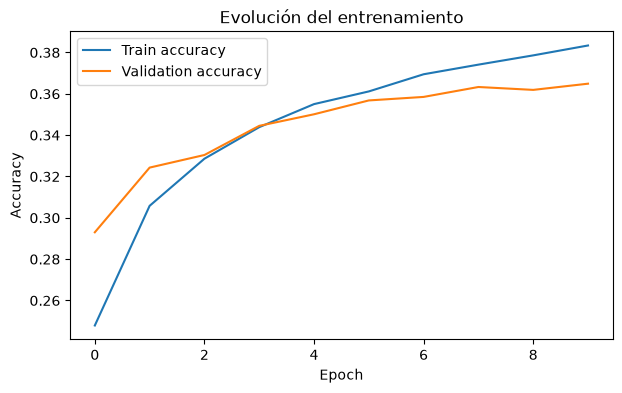

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:** No hay evidencia clara de overfitting. Las dos curvas suben juntas: al final train quedó en 0.383 y validación en 0.365, una diferencia de menos de 2 puntos, y la accuracy de validación siguió subiendo hasta la última epoch (aunque cada vez más despacio). El problema de este modelo es más bien underfitting: las dos accuracies son bajas, la red no tiene capacidad suficiente para el problema.

---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [12]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 1.7809
Test accuracy : 0.3649
Accuracy (%)  : 36.49%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:** CIFAR10 en escala de grises es mucho más difícil. Con esta misma red el accuracy fue 36.49 %, mientras que en Fashion MNIST la red FC llegó a 87.31 % en clase. Es mejor que adivinar (10 %), pero muy lejos. En CIFAR los objetos aparecen en distintas posiciones, tamaños y fondos, hay mucha variación dentro de una misma clase (gatos de todos los colores y posturas), y al quitar el color se pierde información útil, por ejemplo el azul del cielo o del mar. En Fashion MNIST las prendas están centradas, sin fondo y siempre del mismo tamaño.

---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


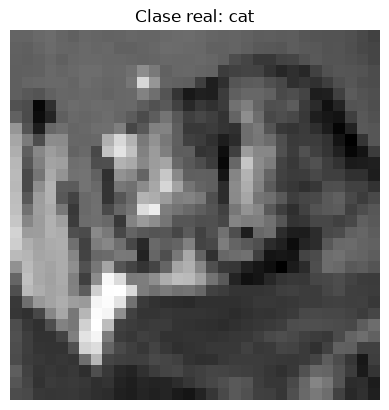

Logits:
[[ 0.9981753  -1.5947696   1.5758052   0.24392425  1.1962814   0.2162365
   0.43944997  0.40920818 -0.13240755 -1.952623  ]]


In [13]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [14]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])

Clase real     : cat
Clase predicha : bird


In [15]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1537
automobile  : 0.0115
bird        : 0.2739 ← predicción
cat         : 0.0723
deer        : 0.1874
dog         : 0.0703
frog        : 0.0879
horse       : 0.0853
ship        : 0.0496
truck       : 0.0080

Suma: 0.9999999


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:** Porque softmax eleva e a cada logit y divide por la suma de todos, entonces cada valor queda entre 0 y 1 y juntos suman 1. Representa cómo el modelo reparte su confianza entre las 10 clases, y como la imagen debe ser exactamente una de ellas, el total es 1. Dio 0.9999999 por redondeo de punto flotante.

---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


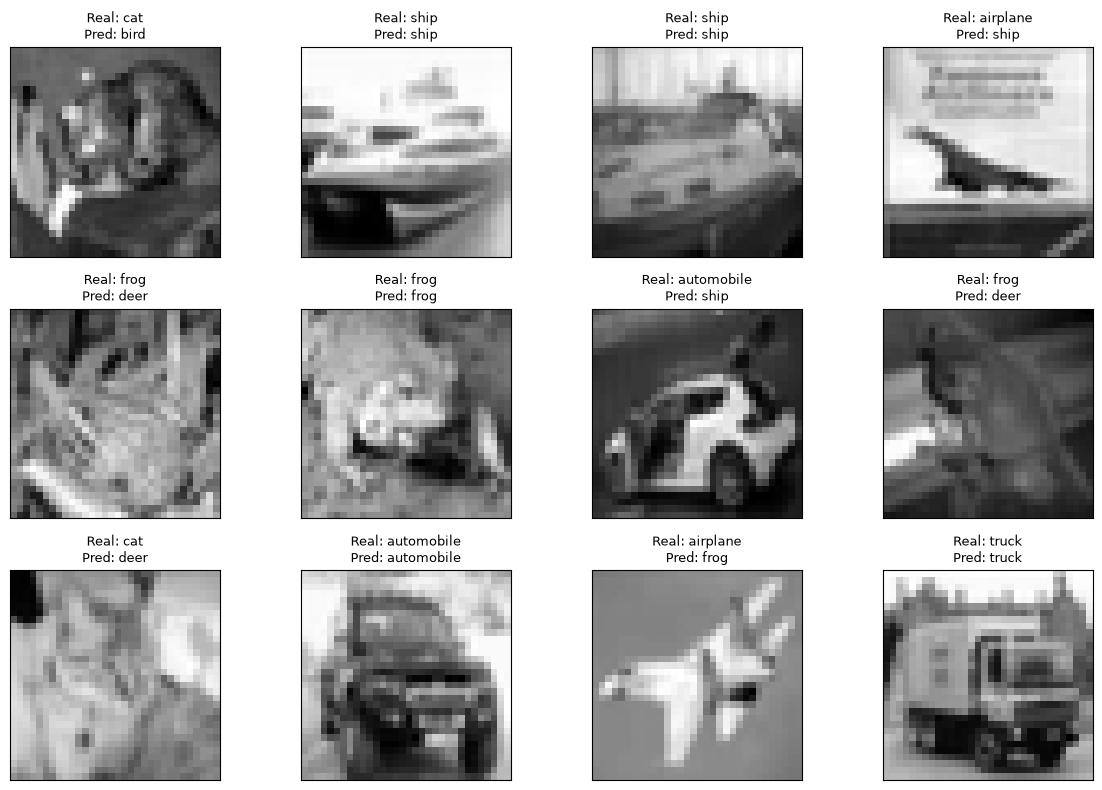

In [16]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


In [17]:
# para la reflexion: accuracy por clase en todo el test
logits_all = model.predict(X_test, batch_size=256, verbose=0)
pred_all = np.argmax(logits_all, axis=1)

for c in range(10):
    acc_c = np.mean(pred_all[y_test == c] == c)
    print(f"{class_names[c]:12s}: {acc_c:.3f}")

confusion = np.zeros((10, 10), dtype=int)
for t, p in zip(y_test, pred_all):
    confusion[t, p] += 1
np.fill_diagonal(confusion, 0)
idx = np.dstack(np.unravel_index(np.argsort(confusion.ravel())[::-1], confusion.shape))[0][:5]
print("\nConfusiones mas frecuentes:")
for t, p in idx:
    print(f"{class_names[t]} predicho como {class_names[p]}: {confusion[t, p]}")

airplane    : 0.412
automobile  : 0.398
bird        : 0.321
cat         : 0.193
deer        : 0.369
dog         : 0.289
frog        : 0.296
horse       : 0.392
ship        : 0.583
truck       : 0.396

Confusiones mas frecuentes:
airplane predicho como ship: 204
automobile predicho como ship: 191
bird predicho como deer: 182
truck predicho como ship: 177
automobile predicho como truck: 169


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:** El accuracy final en test fue **0.3649 (36.49 %)**, con loss de 1.78.

### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:** Según la accuracy por clase, las más difíciles fueron cat (19.3 %), dog (28.9 %), frog (29.6 %) y bird (32.1 %), es decir los animales. La mejor fue ship con 58.3 %. Las confusiones más frecuentes fueron airplane predicho como ship (204), automobile como ship (191), bird como deer (182), truck como ship (177) y automobile como truck (169). Parece que el modelo usa mucho el fondo: barcos y aviones tienen fondos claros y lisos (mar y cielo), y los animales tienen fondos de pasto o tierra parecidos entre sí. En las 12 predicciones solo acertó 5.

### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:** Se pierde la relación entre píxeles vecinos. Después de Flatten la red no sabe qué píxel está al lado de cuál, entonces no puede reconocer directamente bordes, esquinas o formas como una oreja o una rueda. Además si el objeto se mueve unos píxeles, el vector cambia por completo y la red lo ve como algo totalmente diferente, entonces tiene que aprender el mismo patrón en cada posición por separado.

### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:** Una red convolucional (CNN). Usa filtros pequeños que recorren toda la imagen, así detecta patrones locales como bordes y texturas sin importar dónde estén, comparte los pesos y necesita muchos menos parámetros. Con capas de pooling y varias capas convolucionales puede ir combinando bordes en formas y formas en objetos.

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.